# Generate Fish Pool

Generates `tools/fish_pool.csv` with one row per fish with all attributes already rolled.

**Workflow:**
1. Adjust config below and re-run all cells
2. Review `fish_pool.csv` — hand-edit any individual rows as needed
3. Run `python tools/generate_fish_json.py` to push the CSV to `project/data/fish_data.json`, which will be read by Godot

In [1]:
import random
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

## Configuration

Edit values here, then re-run all cells to regenerate the pool.

In [2]:
RANDOM_SEED = 42        # Change or set to None for a different result each run
#RANDOM_SEED = None        # Uncomment this line to get a different result each run
FISH_COUNT  = 50        # Number of standard fish to generate

STANDARD_FISH = {
    "species":        "rainbow_trout",
    "length_mean":    12.0,  # inches
    "length_std":     2.0,

    # Weight power law: weight = a * length ^ b
    # a = density/shape factor. How chonky is this species of fish? Higher a = heavier fish at all lengths.
    # b = growth exponent. How does weight scale with length? Higher b = heavier fish at longer lengths.
    # a=0.00041, b=3.0 gives ~0.71 lbs at 12 inches, ~1.68 lbs at 16 inches
    # a=0.00043, b=3.0 gives ~0.74 lbs at 12 inches, ~1.76 lbs at 16 inches
    "weight_a":       0.00043,
    "weight_b":       3.0,
    "condition_std":  0.08,  # multiplicative noise on weight (~±8%); set to 0 for deterministic

    "tick_min":       5,     # seconds (fastest fish)
    "tick_max":       45,    # seconds (laziest fish)
}

TROPHY_FISH = [
    {
        "species":      "rainbow_trout",
        "length":       25.9,
        "weight":       7.8,
        "movement_tick_interval":     20.0,
        "bite_check_interval":    8.0,
        "trophy_name":  "Scruffy the Cleanly",
        "trophy_title": "the Cleanly",
        "notes":        "He's got a moustache!",
    },
    {
        "species":      "brown_trout",
        "length":       23.2,
        "weight":       6.2,
        "movement_tick_interval":     25.0,
        "bite_check_interval":    7.0,
        "trophy_name":  "Sally the Civilized",
        "trophy_title": "the Civilized",
        "notes":        "She's beautiful!",
    },
    {
        "species":      "brook_trout",
        "length":       22.2,
        "weight":       6.0,
        "movement_tick_interval":     45.0,
        "bite_check_interval":    10.0,
        "trophy_name":  "Old Smokey the Wise",
        "trophy_title": "the Wise",
        "notes":        "Look at those spots!",
    },
]

# Bite check interval: per-fish Gamma distribution
# mean = alpha * theta = 6s  |  mode = (alpha - 1) * theta = 3s  |  floor = 2s
BITE_CHECK = {
    "alpha": 2.0,   # shape parameter
    "theta": 3.0,   # scale parameter
    "min":   2.0,   # floor in seconds — no fish checks faster than this
}


## Generate Fish

In [3]:
rng = random.Random(RANDOM_SEED)

def roll_normal(mean, std):
    return max(0.01, rng.gauss(mean, std))

def roll_uniform(lo, hi):
    return rng.uniform(lo, hi)

def roll_weight(length, a, b, condition_std):
    base = a * (length ** b)
    if condition_std > 0:
        base *= max(0.1, rng.gauss(1.0, condition_std))
    return base

def roll_gamma(alpha, theta, minimum):
    """Sample from Gamma(alpha, theta) with a hard floor. Uses Python's random.gammavariate."""
    return max(minimum, rng.gammavariate(alpha, theta))

rows = []

# Standard fish
for i in range(1, FISH_COUNT + 1):
    cfg  = STANDARD_FISH
    lgth = roll_normal(cfg["length_mean"], cfg["length_std"])
    wt   = roll_weight(lgth, cfg["weight_a"], cfg["weight_b"], cfg["condition_std"])

    rows.append({
        "id":                     i,
        "species":                cfg["species"],
        "length":                 round(lgth, 2),
        "weight":                 round(wt, 3),
        "movement_tick_interval": round(roll_uniform(cfg["tick_min"], cfg["tick_max"]), 1),
        "bite_check_interval":    round(roll_gamma(BITE_CHECK["alpha"], BITE_CHECK["theta"], BITE_CHECK["min"]), 2),
        "is_trophy":              False,
        "trophy_name":            "",
        "trophy_title":           "",
        "notes":                  "",
    })

# Trophy fish — all attributes hand-set in config, no rolling
for t in TROPHY_FISH:
    rows.append({
        "id":                     len(rows) + 1,
        "species":                t["species"],
        "length":                 t["length"],
        "weight":                 t["weight"],
        "movement_tick_interval": t["movement_tick_interval"],
        "bite_check_interval":    t["bite_check_interval"],
        "is_trophy":              True,
        "trophy_name":            t["trophy_name"],
        "trophy_title":           t["trophy_title"],
        "notes":                  t["notes"],
    })

df = pd.DataFrame(rows)
print(f"{len(df)} fish generated ({FISH_COUNT} standard, {len(TROPHY_FISH)} trophy)")
df


53 fish generated (50 standard, 3 trophy)


,id,species,length,weight,movement_tick_interval,bite_check_interval,is_trophy,trophy_name,trophy_title,notes
0,1,rainbow_trout,11.71,0.681,16.0,2.92,False,,,
1,2,rainbow_trout,10.12,0.379,8.5,5.00,False,,,
2,3,rainbow_trout,12.46,0.910,6.1,2.68,False,,,
3,4,rainbow_trout,10.64,0.510,28.6,13.64,False,,,
4,5,rainbow_trout,11.38,0.658,43.3,4.06,False,,,
5,6,rainbow_trout,15.18,1.639,29.1,13.71,False,,,
6,7,rainbow_trout,6.76,0.126,20.1,6.77,False,,,
7,8,rainbow_trout,9.07,0.287,28.1,2.97,False,,,
8,9,rainbow_trout,13.28,1.035,9.0,3.46,False,,,
9,10,rainbow_trout,10.73,0.562,13.4,3.35,False,,,


## Visualize
Only visualize the standard fish

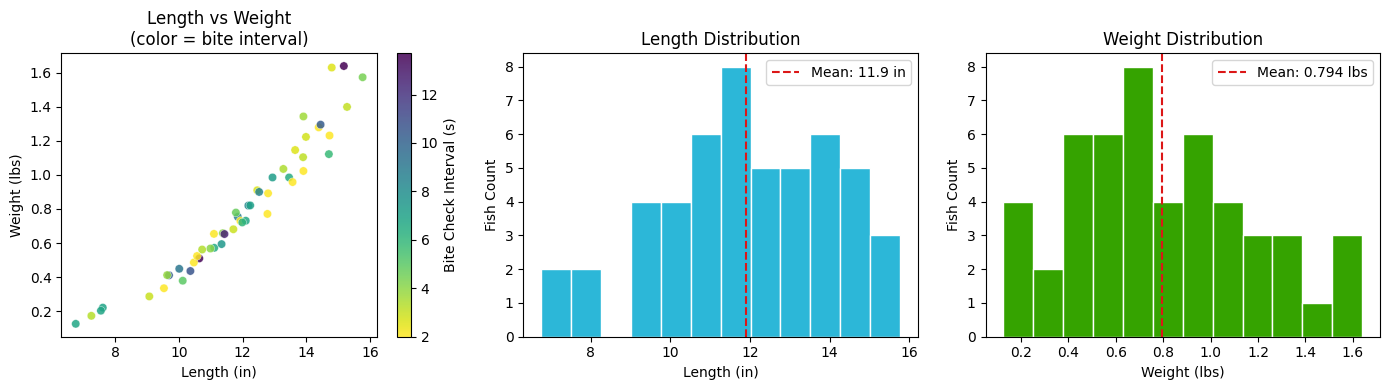

In [9]:
stdfish = df[df["is_trophy"] == False]

fig, (ax_scatter, ax_len, ax_wt) = plt.subplots(1, 3, figsize=(14, 4))

# Scatter: length vs weight, colored by bite check interval
scatter = ax_scatter.scatter(
    stdfish["length"],
    stdfish["weight"],
    c=stdfish["bite_check_interval"],
    cmap="viridis_r",
    alpha=0.85,
    edgecolors="white",
    linewidths=0.3,
)
fig.colorbar(scatter, ax=ax_scatter, label="Bite Check Interval (s)")
ax_scatter.set_xlabel("Length (in)")
ax_scatter.set_ylabel("Weight (lbs)")
ax_scatter.set_title("Length vs Weight\n(color = bite interval)")

# Histogram: fish length
ax_len.hist(stdfish["length"], bins=12, color="#2CB7D8", edgecolor="white")
ax_len.axvline(stdfish["length"].mean(), color="#DC1717", linestyle="--", label=f"Mean: {stdfish['length'].mean():.1f} in")
ax_len.set_xlabel("Length (in)")
ax_len.set_ylabel("Fish Count")
ax_len.set_title("Length Distribution")
ax_len.legend()

# Histogram: fish weight
ax_wt.hist(stdfish["weight"], bins=12, color="#35A300", edgecolor="white")
ax_wt.axvline(stdfish["weight"].mean(), color="#DC1717", linestyle="--", label=f"Mean: {stdfish['weight'].mean():.3f} lbs")
ax_wt.set_xlabel("Weight (lbs)")
ax_wt.set_ylabel("Fish Count")
ax_wt.set_title("Weight Distribution")
ax_wt.legend()

plt.tight_layout()
plt.show()


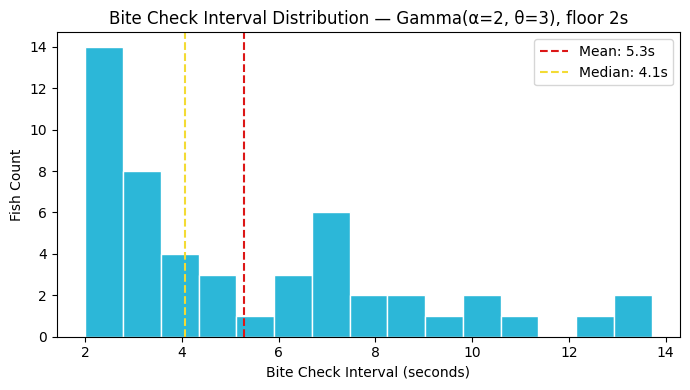

min: 2.00s  max: 13.71s  mean: 5.29s  median: 4.06s


In [5]:
# Bite check interval distribution (standard fish only)
stdfish = df[df["is_trophy"] == False]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(stdfish["bite_check_interval"], bins=15, color="#2CB7D8", edgecolor="white")
ax.axvline(stdfish["bite_check_interval"].mean(), color="#DC1717", linestyle="--", label=f"Mean: {stdfish['bite_check_interval'].mean():.1f}s")
ax.axvline(stdfish["bite_check_interval"].median(), color="#F3DB34", linestyle="--", label=f"Median: {stdfish['bite_check_interval'].median():.1f}s")
ax.set_xlabel("Bite Check Interval (seconds)")
ax.set_ylabel("Fish Count")
ax.set_title("Bite Check Interval Distribution — Gamma(α=2, θ=3), floor 2s")
ax.legend()
plt.tight_layout()
plt.show()

print(f"min: {stdfish['bite_check_interval'].min():.2f}s  "
      f"max: {stdfish['bite_check_interval'].max():.2f}s  "
      f"mean: {stdfish['bite_check_interval'].mean():.2f}s  "
      f"median: {stdfish['bite_check_interval'].median():.2f}s")


## Export to CSV

Writes `tools/fish_pool.csv`. Review and hand-edit that file before running `generate_fish.py`.

In [ ]:
# write out the CSV into the parent directory of the current directory. This file will get picked up
# by generate_fish_json.py and converted into JSON for use in Godot.
output_path = os.path.normpath(os.path.join(os.getcwd(), "..", "fish_pool.csv"))
df.to_csv(output_path, index=False)
print(f"Wrote {os.path.basename(output_path)}")

Wrote c:\Users\Chris\OneDrive\Documents\GitHub\trout-derby\tools\fish_pool.csv
